# Clean up FNO pipeline

This is for the 2D Darcy problem on [0, 1]^2, with input permeability field discrete in {0, 1}.

In [18]:
# Imports
import numpy as np
import sys

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, Matern

import torch
from torch.utils.data import DataLoader

import neuralop
from neuralop.models import FNO
from neuralop import Trainer, LpLoss, H1Loss
from neuralop.training import AdamW
from neuralop.data.datasets import load_darcy_flow_small, DarcyDataset
from neuralop.utils import count_model_params

import matplotlib.pyplot as plt


In [19]:
# ===== HYPERPARAMETERS =====

# === Data ===
data_n_train = 1000
data_n_tests = [100, 50]
data_train_resolution = 16
data_test_resolutions = [16, 32]
data_batch_size = 32
data_test_batch_sizes = [32, 32]

# === Model ===
FNO_n_modes=(16, 16)
FNO_in_channels=1
FNO_out_channels=1
FNO_hidden_channels=32  # Width of model. Documentation recommends 64, but 32 is sufficient for our purposes and much faster to train.
FNO_n_layers = 4  # Number of Fourier layers.
FNO_projection_channel_ratio=2
FNO_factorization="tucker"
FNO_rank=0.42

# === Training ===
TRAIN_epochs = 100


In [20]:
# Activate GPU (if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [21]:
# Import Data
# Loading the Darcy-Flow dataset

dataset = DarcyDataset(
    root_dir="./darcy_data",
    n_train=data_n_train,
    n_tests=data_n_tests,
    train_resolution=data_train_resolution,
    batch_size=data_batch_size,
    test_resolutions=data_test_resolutions,
    test_batch_sizes=data_test_batch_sizes,
)

train_loader = DataLoader(
        dataset.train_db,
        batch_size=data_batch_size,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

test_loaders = {}
for res, test_bsize in zip(data_test_resolutions, data_test_batch_sizes):
    test_loaders[res] = DataLoader(
        dataset.test_dbs[res],
        batch_size=test_bsize,
        shuffle=False,
        num_workers=1,
        pin_memory=True,
        persistent_workers=False,
    )

data_processor = dataset.data_processor



Loading test db for resolution 16 with 100 samples 
Loading test db for resolution 32 with 50 samples 


In [22]:
print(len(dataset.test_dbs[16]))
print(len(dataset.test_dbs[32]))

50
50


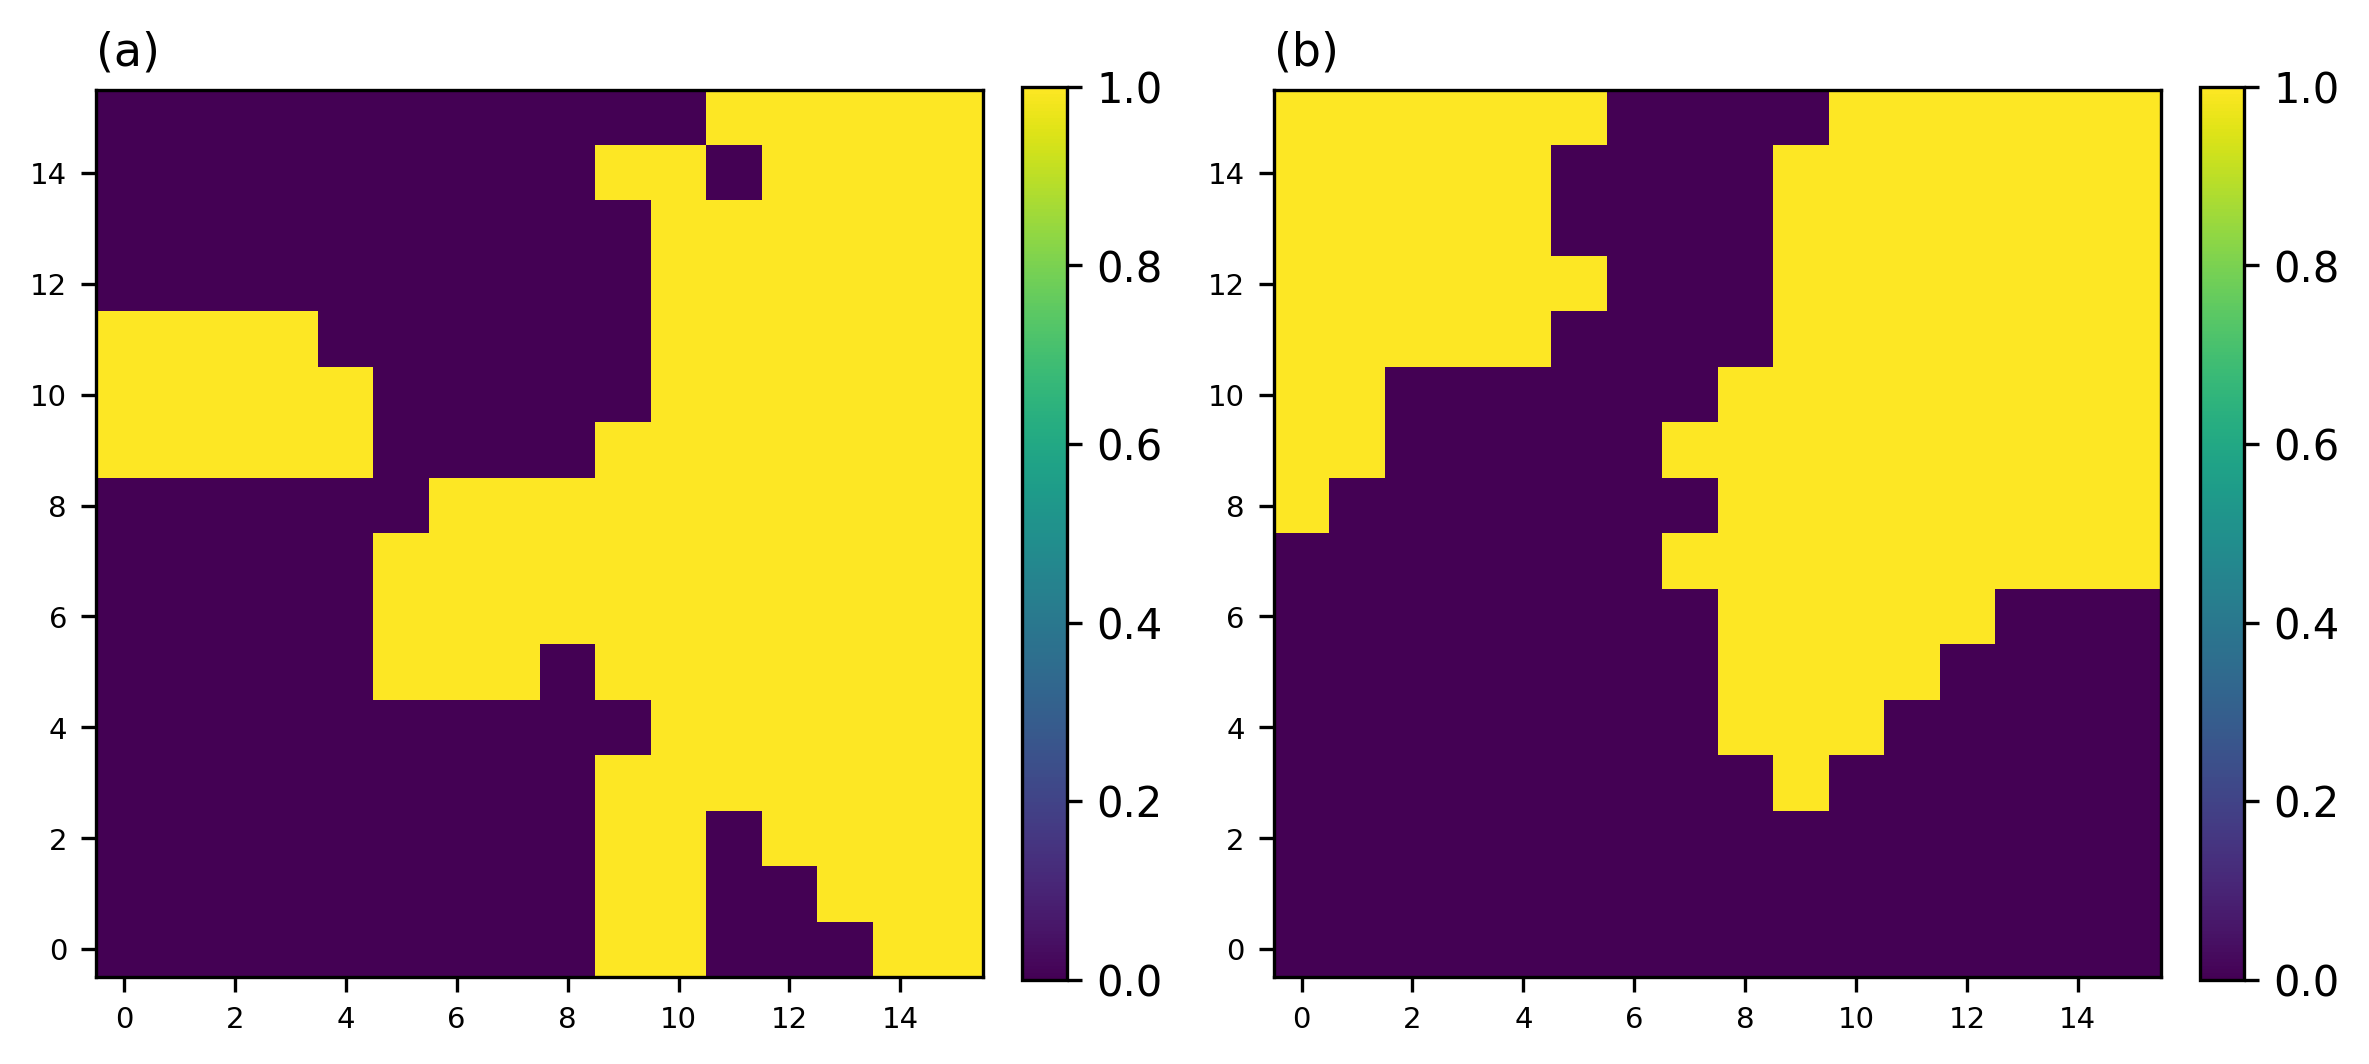

In [23]:
# visualise two examples of the field a(x)

tf1 = dataset.test_dbs[16].x[0, 0].unsqueeze(0).unsqueeze(0)
tf2 = dataset.test_dbs[16].x[1, 0].unsqueeze(0).unsqueeze(0)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, tf, label in zip(axs, [tf1, tf2], ['(a)', '(b)']):
    im = ax.imshow(tf[0, 0], cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(label, fontsize=11, loc='left', pad=6)
    ax.set_xticks(range(0,16, 2))
    ax.set_yticks(range(0,16, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# fig.suptitle('Coefficient field $a(x)$', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('coefficient_fields.png', bbox_inches='tight', dpi=300)
plt.show()

In [24]:
# Instantiate Model
model = FNO(
    n_modes=FNO_n_modes,
    in_channels=FNO_in_channels,
    out_channels=FNO_out_channels,
    hidden_channels=FNO_hidden_channels,
    n_layers=FNO_n_layers,
    projection_channel_ratio=FNO_projection_channel_ratio,
    factorization=FNO_factorization,
    rank=FNO_rank,
)

# NOTE: FNO takes in inputs of shape (batch_size, in_channels, height, width) and outputs the same shape.
# If you want to pass a single observation, you need to add batch and channel dimensions, e.g., x[0, 0].unsqueeze(0).unsqueeze(0) to get shape (1, 1, 16, 16).

model = model.to(device)

n_params = count_model_params(model)
print(f"\nOur model has {n_params} parameters.")
sys.stdout.flush()


# Scheduler and Loss

optimizer = AdamW(model.parameters(), lr=8e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

l2loss = LpLoss(d=2, p=2)
h1loss = H1Loss(d=2)

train_loss = h1loss
eval_losses = {"h1": h1loss, "l2": l2loss}



Our model has 520761 parameters.


In [25]:
# Train model
# Creating the trainer

trainer = Trainer(
    model=model,
    n_epochs=TRAIN_epochs,
    device=device,
    data_processor=data_processor,
    wandb_log=False,
    eval_interval=3,
    use_distributed=False,
    verbose=True,
)

# We train and save checkpoints

trainer.train(
    train_loader=train_loader,
    test_loaders={},
    optimizer=optimizer,
    scheduler=scheduler,
    regularizer=False,
    training_loss=train_loss,
    save_every=1,
    save_dir="./checkpoints",
)

# Look at FNO.ipynb for how to train from saved checkpoints instead of from scratch. For now no need to do so since training is very fast (a few minutes on GPU).

Training on 1000 samples
Testing on [] samples         on resolutions [].


/home/ghazi/Desktop/Academic/M4R/M4R_venv/lib/python3.14/site-packages/torch/nn/modules/module.py:1787: UserWarning: FNO.forward() received unexpected keyword arguments: ['y']. These arguments will be ignored.
  return forward_call(*args, **kwargs)


Raw outputs of shape torch.Size([32, 1, 16, 16])


/home/ghazi/Desktop/Academic/M4R/M4R_venv/lib/python3.14/site-packages/neuralop/training/trainer.py:536: UserWarning: H1Loss.__call__() received unexpected keyword arguments: ['x']. These arguments will be ignored.
  loss += training_loss(out, **sample)


[0] time=2.42, avg_loss=0.6467, train_err=20.2080
Eval: 
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoints
[3] time=1.37, avg_loss=0.2495, train_err=7.7983
Eval: 
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoints
[6] time=1.38, avg_loss=0.2014, train_err=6.2946
Eval: 
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoints
[9] time=1.38, avg_loss=0.1766, train_err=5.5181
Eval: 
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoints
[12] time=1.37, avg_loss=0.1566, train_err=4.8929
Eval: 
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoints
[Rank 0]: saved training state to ./checkpoint

{'train_err': 1.8604900855571032,
 'avg_loss': 0.0595356827378273,
 'avg_lasso_loss': None,
 'epoch_train_time': 2.2159747739988234}

In [26]:
# === MCMC HYPERPARAMETERS ===
MCMC_delta = 0.00025  # can experiment later with adaptive delta, as in it gets smaller as the number of iterations increases.
MCMC_n_iterations = 10_000  # Most likely need it on the order of 100,000 to get good results, but we can test the code with fewer iterations first.


In [27]:
# MCMC helper functions

def log_likelihood(x: torch.Tensor, y: torch.Tensor, model, sigma=1.0) -> torch.Tensor:
    """Inputs:
    - x: input tensor (location measurements of field θ)
    - y: observed output tensor (e.g., solution field u at locations x)
    - model: the trained FNO model that maps x to predicted y
    - sigma: standard deviation of the Gaussian likelihood
    Returns:
    - log-likelihood of observing y given x under the model's predictions"""
    # Ensure x and y are 4D tensors with shape (1, 1, height, width)
    # Ensure both x and y are on the same device as the model
    x = x.to(device)
    y = y.to(device)
    # Assuming Gaussian likelihood with fixed variance
    with torch.no_grad():
        forwards = model(x)
        mean = data_processor.out_normalizer.mean  # need to unnormalize the model outputs before comparing to y, since the model was trained on normalized data
        std = data_processor.out_normalizer.std
        forwards = forwards * std + mean
    forwards = forwards[0, 0]  # need .cpu() before .numpy()
    residuals = (y - forwards).cpu().numpy()
    ll = -0.5 * np.sum(residuals**2)/sigma**2
    return ll


def sample_GP(dimension=16,kernel=RBF):
    # create 2D grid over [0,1] x [0,1]
    x_coords = np.linspace(0, 1, dimension)
    y_coords = np.linspace(0, 1, dimension)
    X, Y = np.meshgrid(x_coords, y_coords)

    # flatten grid to (1024, 2) for GP input
    grid_points = np.column_stack([X.ravel(), Y.ravel()])

    kernel = RBF(length_scale=0.3)
    gp = GaussianProcessRegressor(kernel=kernel)

    # sample one realisation
    sample = gp.sample_y(grid_points, n_samples=1, random_state=None)  # pass keyword random_state=None to obtain other sdifferent sample each time, otherwise it will be the same sample each time
    sample_2d = sample.reshape(dimension, dimension)
    return sample_2d


def smooth_threshold(x, tau=10):
    """A smooth approximation to the step function, which can be used to get a binary field from the GP sample while maintaining differentiability.
    
    See Akiyldiz for details.
    """

    return 0.5 * np.tanh(tau * x) + 0.5

In [28]:
def T_push(x):
    return (x >= 0).astype(float)

<class 'numpy.ndarray'>


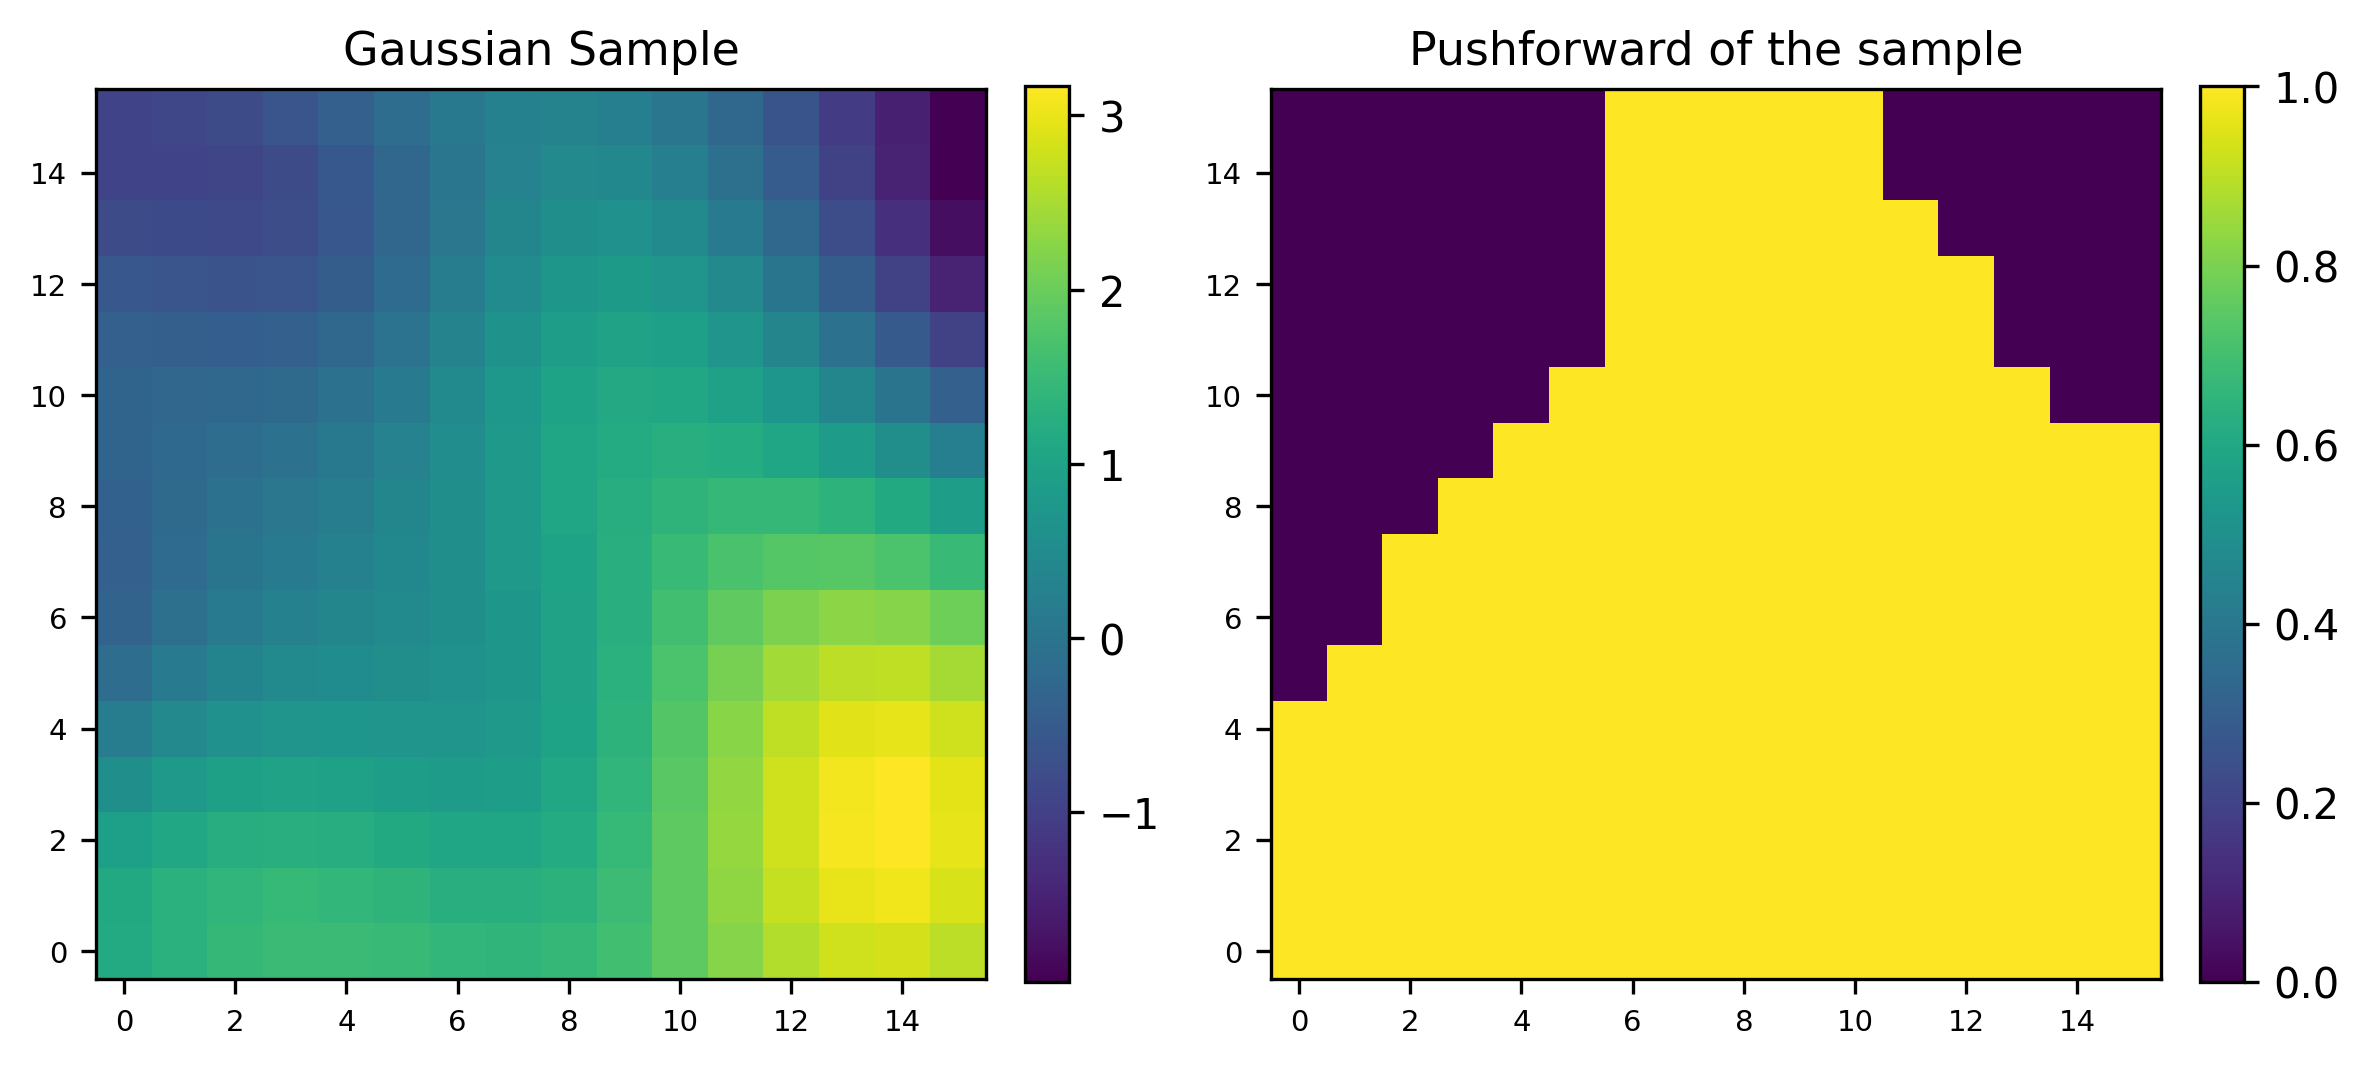

In [ ]:
# visualise two examples of the field a(x)

tf1 = sample_GP(dimension=16)
tf2 = T_push(tf1)

print(type(tf1))
fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, tf, label in zip(axs, [tf1, tf2], ["Gaussian Sample", 'Pushforward of the sample']):
    im = ax.imshow(tf, cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(label, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0,16, 2))
    ax.set_yticks(range(0,16, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# fig.suptitle('Coefficient field $a(x)$', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('coefficient_fields.png', bbox_inches='tight', dpi=300)
plt.show()

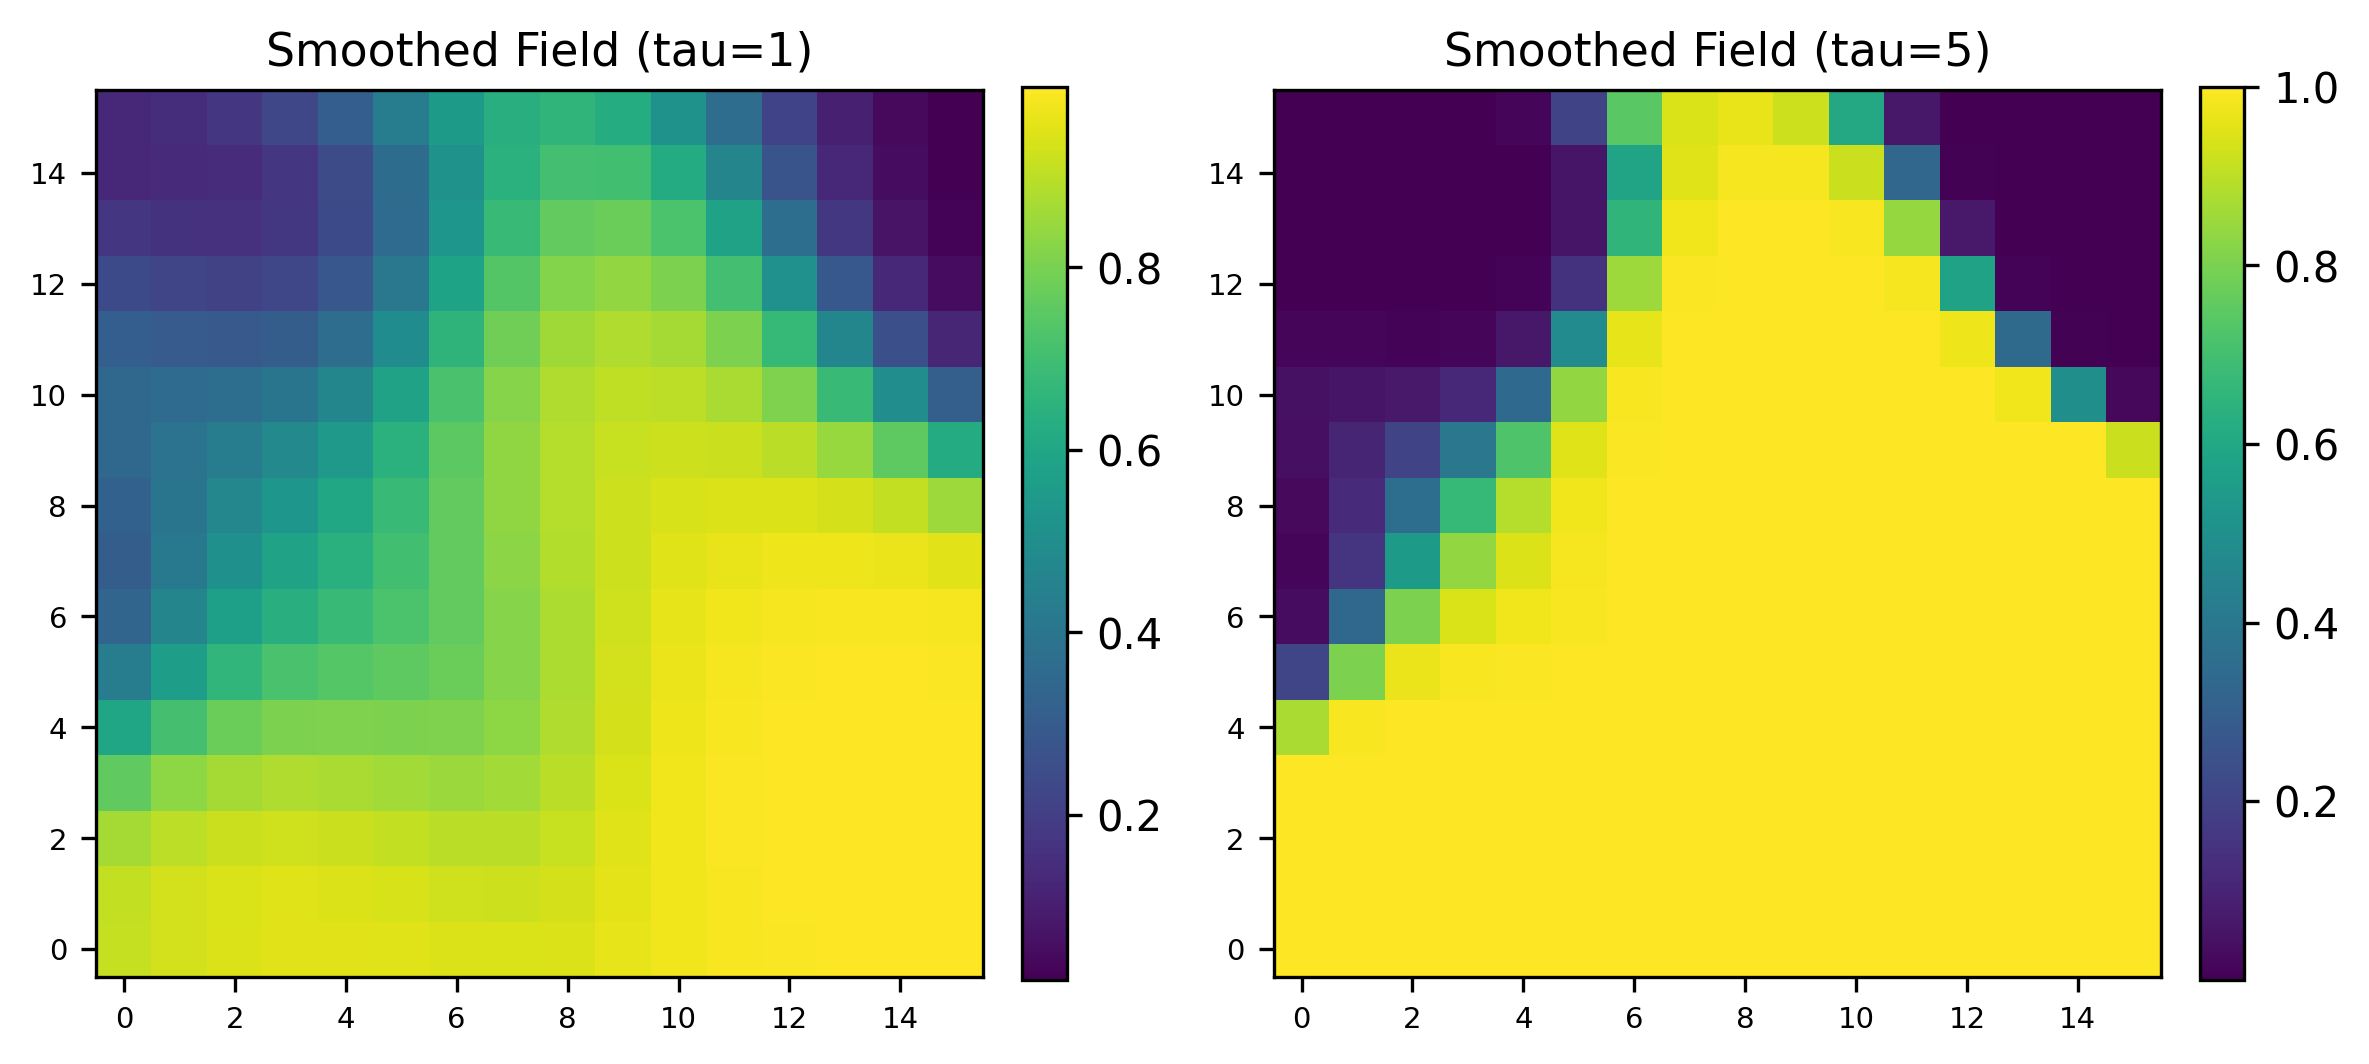

In [30]:
smooth1 = smooth_threshold(tf1, tau=1)
smooth2 = smooth_threshold(tf1, tau=5)

fig, axs = plt.subplots(1, 2, figsize=(8, 4), dpi=300)

for ax, smooth, label in zip(axs, [smooth1, smooth2], ["Smoothed Field (tau=1)", "Smoothed Field (tau=5)"]):
    im = ax.imshow(smooth, cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(label, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0,16, 2))
    ax.set_yticks(range(0,16, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# fig.suptitle('Coefficient field $a(x)$', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('tau_smooth_coefficient_fields.png', bbox_inches='tight', dpi=300)
plt.show()

In [31]:
# Get true field from test set
true_field = dataset.test_dbs[16].x[0, 0].unsqueeze(0).unsqueeze(0)  # shape (1, 1, 16, 16)
true_observations = dataset.test_dbs[16].y[0, 0].unsqueeze(0).unsqueeze(0)  # shape (1, 1, 16, 16)
sigma = true_observations.std().item()

# Instantiate MCMC
accepted = 0  # counter for accepted proposals
u_0 = sample_GP()  # Initial proposal
theta_0 = smooth_threshold(u_0)  # threshold to get binary field
theta_evolution = [theta_0]  # to store the evolution of theta
loss_evolution = []
accepted = []

In [32]:
# Check these
print(true_observations.min(), true_observations.max(), true_observations.mean(), true_observations.std())

# And check what the model outputs raw
with torch.no_grad():
    raw_out = model(true_field.to(device))
print(raw_out.min(), raw_out.max(), raw_out.mean(), raw_out.std())

tensor(0.0002) tensor(0.9406) tensor(0.3554) tensor(0.2678)
tensor(-1.1467, device='cuda:0') tensor(1.7465, device='cuda:0') tensor(-0.0445, device='cuda:0') tensor(0.8132, device='cuda:0')


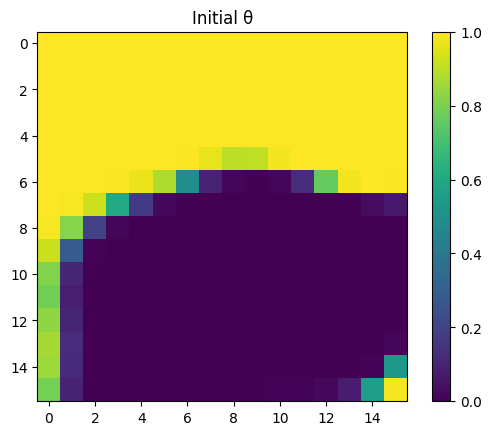

In [33]:
# Plot initial theta, to compare with how it evolves after MCMC loop
plt.imshow(theta_0, cmap='viridis', vmin=0, vmax=1)
plt.colorbar()
plt.title("Initial θ")
plt.show()

In [34]:
# Run MCMC
for i in range(MCMC_n_iterations):
    # single MCMC step
    u_proposal = np.sqrt(1-2*MCMC_delta)*u_0 + np.sqrt(2*MCMC_delta)*sample_GP()
    theta_proposal = smooth_threshold(u_proposal)  # threshold to get binary field

    # Make proposals pytorch tensors, and add batch and channel dimensions to match FNO input shape (1, 1, 16, 16)
    theta_proposal_tensor = torch.tensor(theta_proposal, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
    theta_0_tensor = torch.tensor(theta_0, dtype=torch.float32).unsqueeze(0).unsqueeze(0)


    acceptance_prob = min(1, np.exp(log_likelihood(theta_proposal_tensor, true_observations, model, sigma=sigma) - log_likelihood(theta_0_tensor, true_observations, model, sigma=sigma)))
    if np.random.rand() < acceptance_prob:
        theta_0 = theta_proposal
        u_0 = u_proposal
        accepted += [1]
        theta_evolution.append(theta_0)
    else:
        accepted += [0]
    theta_evolution.append(theta_0)
    loss_evolution.append(log_likelihood(theta_0_tensor, true_observations, model).item())
    if (i+1) % 100 == 0:
        print(f"Iteration {i+1}/{MCMC_n_iterations}, Acceptance Rate: {sum(accepted[-100:])/100:.3f}")



Iteration 100/10000, Acceptance Rate: 0.490
Iteration 200/10000, Acceptance Rate: 0.680
Iteration 300/10000, Acceptance Rate: 0.860
Iteration 400/10000, Acceptance Rate: 0.830
Iteration 500/10000, Acceptance Rate: 0.850
Iteration 600/10000, Acceptance Rate: 0.860
Iteration 700/10000, Acceptance Rate: 0.850
Iteration 800/10000, Acceptance Rate: 0.920
Iteration 900/10000, Acceptance Rate: 0.840
Iteration 1000/10000, Acceptance Rate: 0.920
Iteration 1100/10000, Acceptance Rate: 0.810
Iteration 1200/10000, Acceptance Rate: 0.740
Iteration 1300/10000, Acceptance Rate: 0.760
Iteration 1400/10000, Acceptance Rate: 0.760
Iteration 1500/10000, Acceptance Rate: 0.690
Iteration 1600/10000, Acceptance Rate: 0.780
Iteration 1700/10000, Acceptance Rate: 0.620
Iteration 1800/10000, Acceptance Rate: 0.630
Iteration 1900/10000, Acceptance Rate: 0.680
Iteration 2000/10000, Acceptance Rate: 0.630
Iteration 2100/10000, Acceptance Rate: 0.640
Iteration 2200/10000, Acceptance Rate: 0.620
Iteration 2300/1000

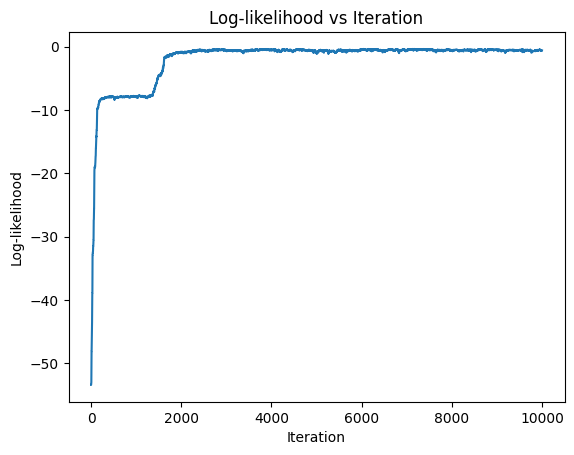

In [35]:
# Plot loss, compare predicted vs true_FNO vs absolute true
plt.plot(loss_evolution)
plt.title("Log-likelihood vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Log-likelihood")
plt.show()

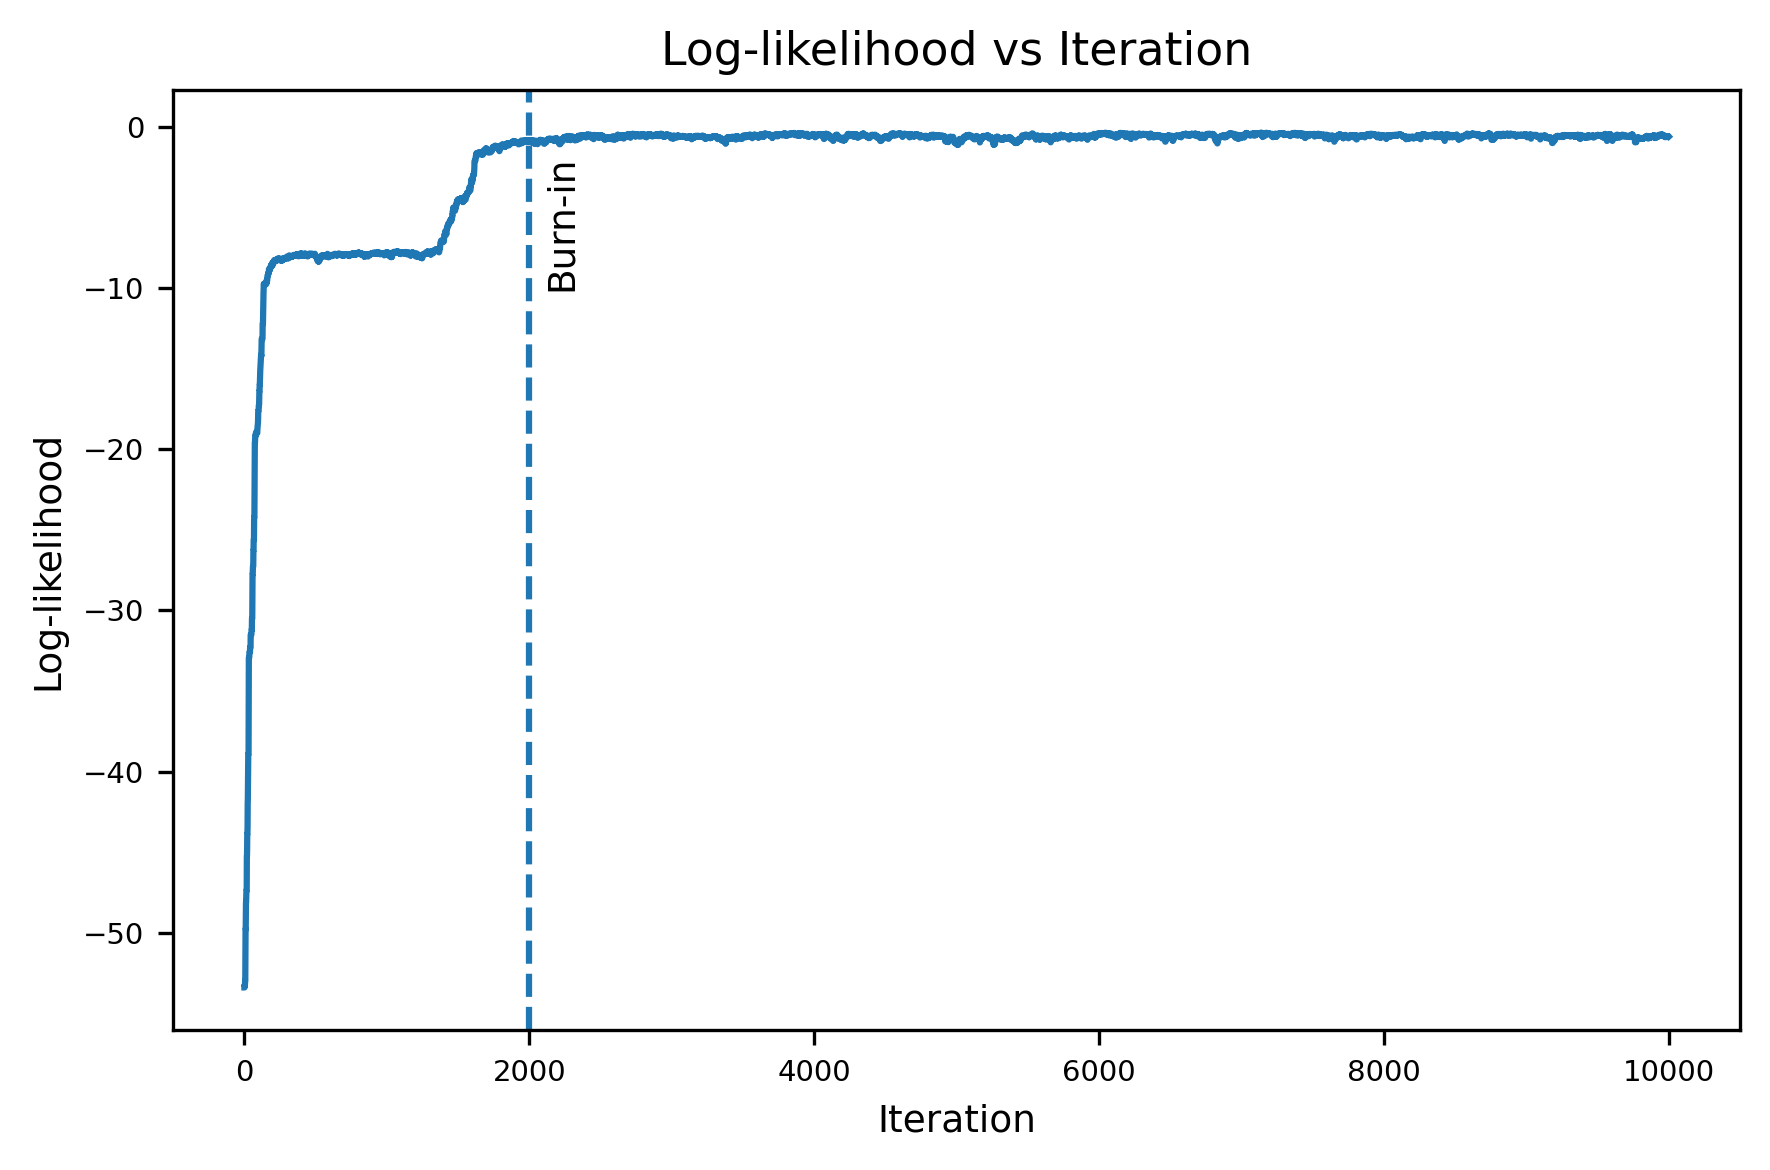

In [56]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4), dpi=300)

burn_in = 2000

ax.plot(loss_evolution)
ax.axvline(burn_in, linestyle='--')

ax.text(
    burn_in + 100,                     # shift slightly right
    max(loss_evolution) * 5,         # near top
    "Burn-in",
    fontsize=9,
    rotation=90,
    va='top'
)

ax.set_title("Log-likelihood vs Iteration", fontsize=11, loc='center', pad=6)
ax.set_xlabel("Iteration", fontsize=9)
ax.set_ylabel("Log-likelihood", fontsize=9)


ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('loss_curve.png', bbox_inches='tight', dpi=300)
plt.show()

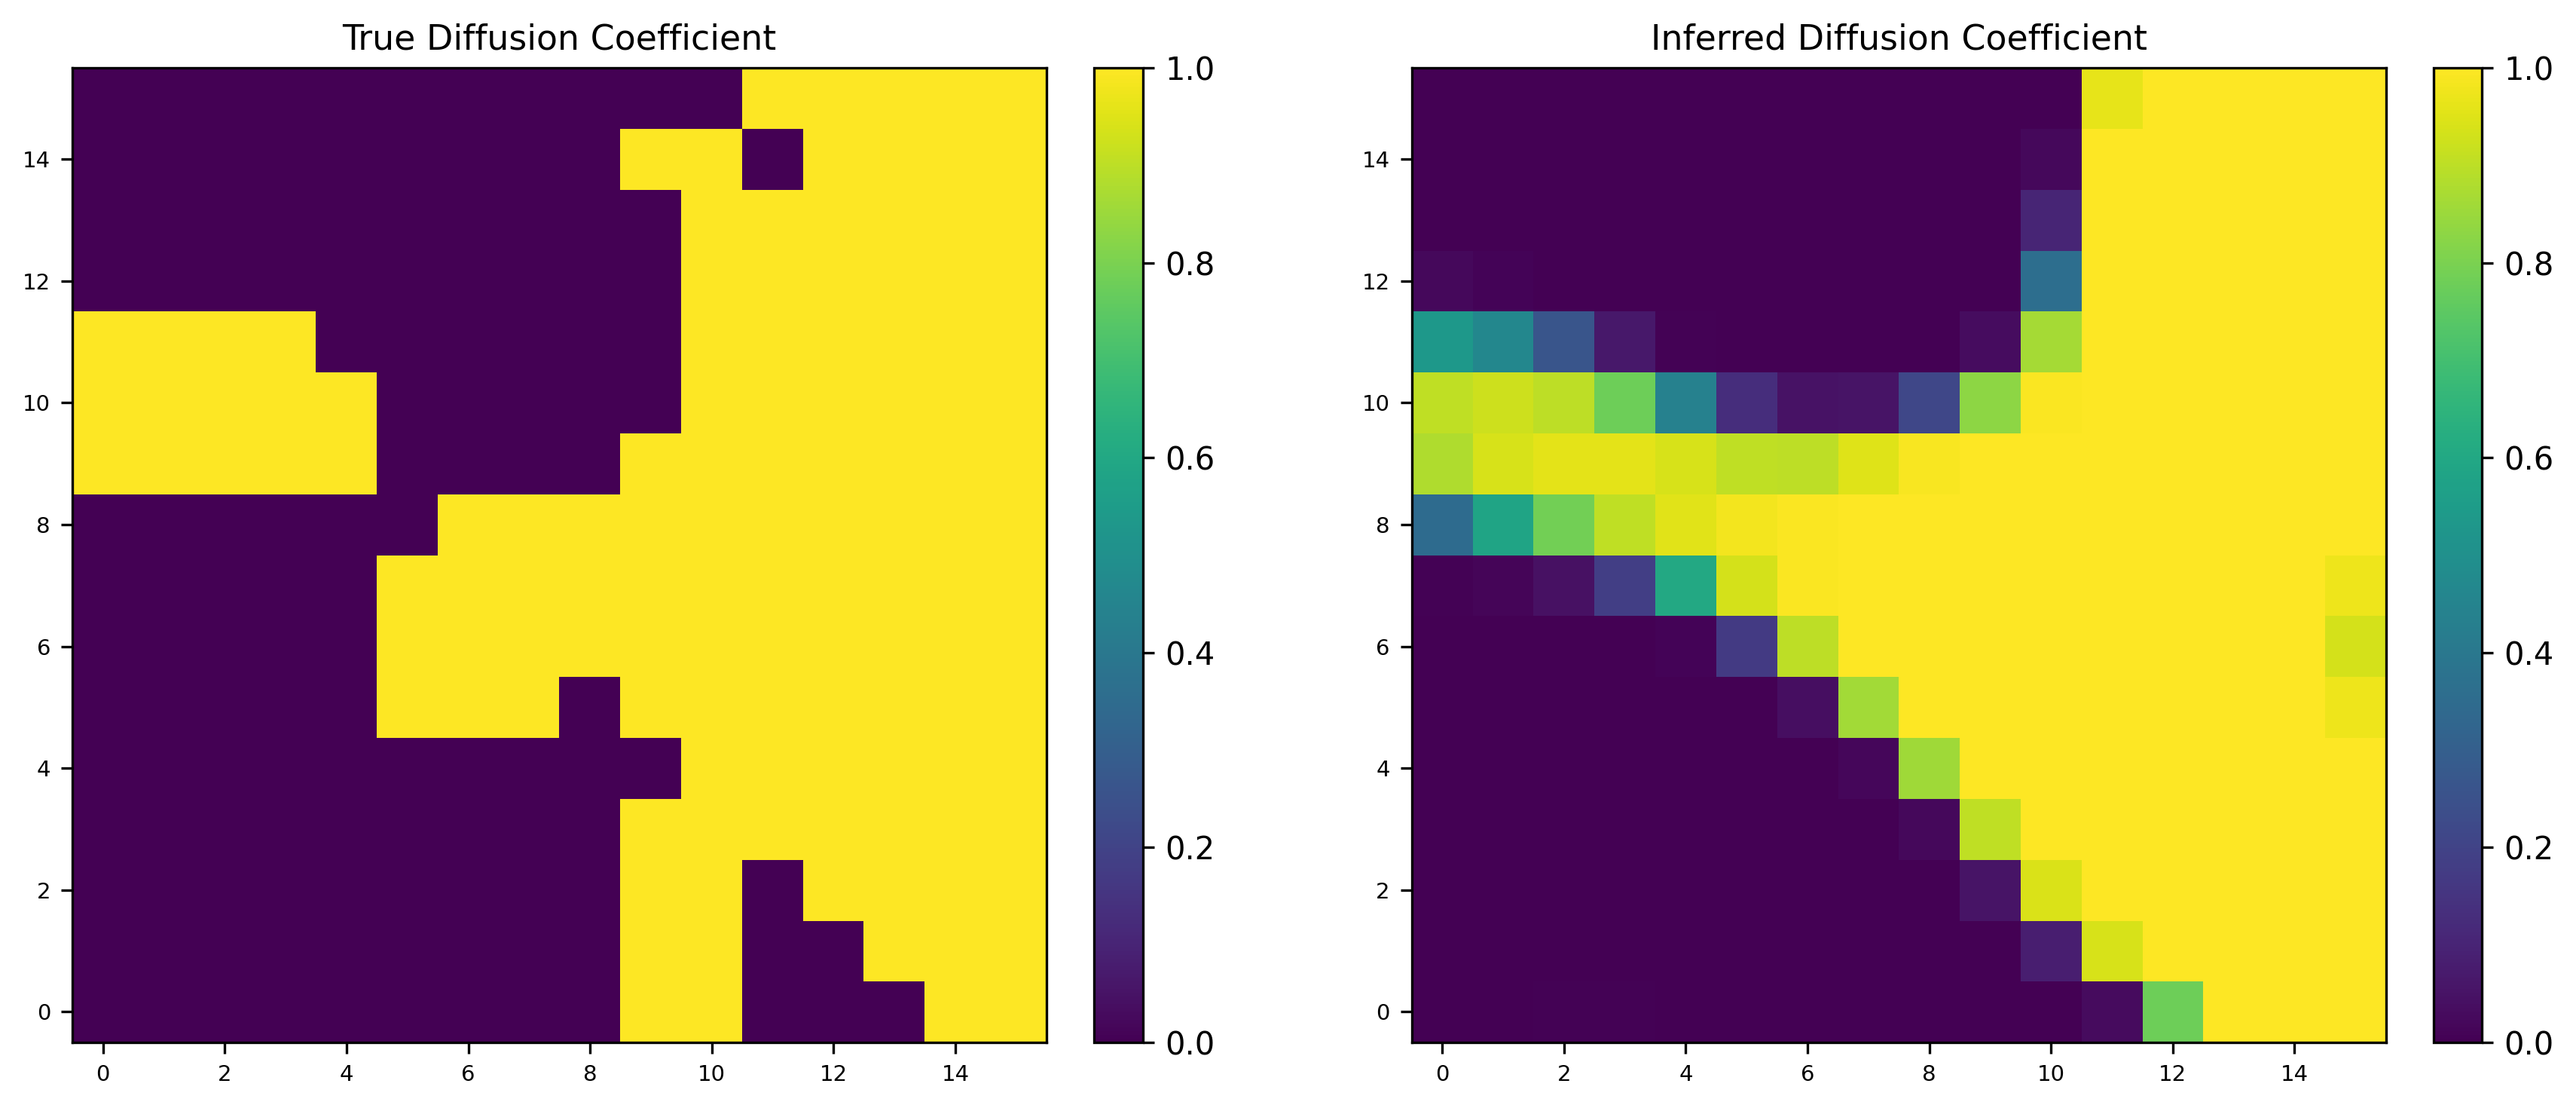

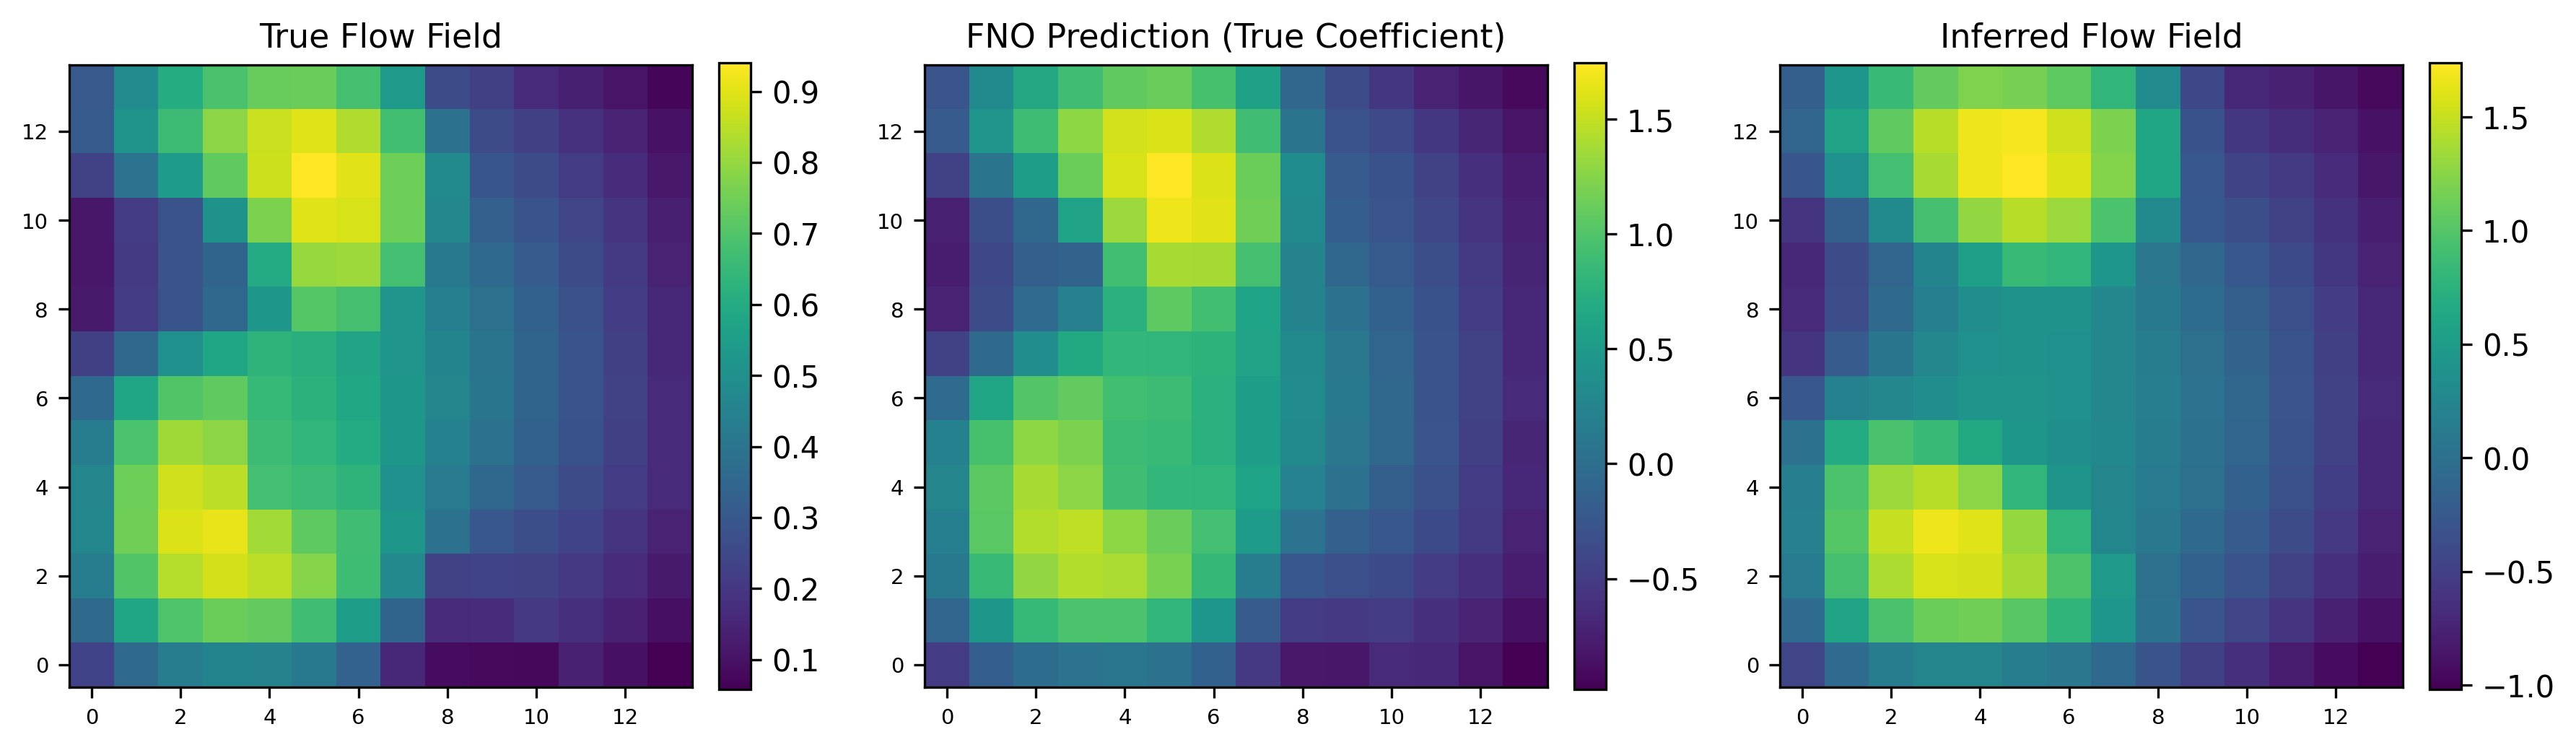

In [83]:
with torch.no_grad():
        forwards = model(true_field[0,0].unsqueeze(0).unsqueeze(0).to(device))

# Compute predicted solution
with torch.no_grad():
    predicted_solution = model(theta_0_tensor.to(device)).cpu().numpy()[0, 0]

# FNO forward pass on true field
fno_prediction = forwards.cpu().numpy()[0, 0]

# ----------------------
# First figure (top row)
# ----------------------
fig1, axs1 = plt.subplots(1, 2, figsize=(12, 5), dpi=300)

fields1 = [
    true_field[0, 0],
    theta_0,
    fno_prediction
]

titles1 = [
    "True Diffusion Coefficient",
    "Inferred Diffusion Coefficient",
]

for ax, field, title in zip(axs1, fields1, titles1):
    im = ax.imshow(field, cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(title, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0, field.shape[0], 2))
    ax.set_yticks(range(0, field.shape[1], 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('true_vs_inferred_coefficients.png', bbox_inches='tight', dpi=300)


# ----------------------
# Second figure (bottom row)
# ----------------------
fig2, axs2 = plt.subplots(1, 3, figsize=(12, 4), dpi=300)

fields2 = [
    true_observations[0, 0],
    fno_prediction,
    predicted_solution,
    
]

titles2 = [
    "True Flow Field",
    "FNO Prediction (True Coefficient)",
    "Inferred Flow Field"
]

for ax, field, title in zip(axs2, fields2, titles2):
    im = ax.imshow(field[1:field.shape[0]-1, 1:field.shape[1]-1], cmap='viridis', interpolation='nearest', origin='lower')
    ax.set_title(title, fontsize=11, loc='center', pad=6)
    ax.set_xticks(range(0, field.shape[0]-2, 2))
    ax.set_yticks(range(0, field.shape[1]-2, 2))
    ax.tick_params(labelsize=7)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.savefig('true_vs_inferred_flows.png', bbox_inches='tight', dpi=300)

plt.show()